# Question : Is timing internally generated or stimulus driven ?
* The population variance profile is tightly locked to the stimulus onset and does not show the characteristic increase in variability associated with internally generated temporal accumulation, indicating a stimulus-driven timing strategy

In [1]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 18.6 MB/s eta 0:00:00


In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x132487314475680
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x132487318839632
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import torch 
import torch.nn as nn

In [5]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
spike_times = units['spike_times'][0]

print(spike_times[:20])
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]
First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [10]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [11]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [13]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [14]:
# Check for trial or stimulus information
print(nwbfile.intervals.keys())

# If intervals exist, let's see the structure of the first one
if 'trials' in nwbfile.intervals:
    print(nwbfile.intervals['trials'].colnames)

dict_keys(['trials'])
('start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time', 'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time', 'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur', 'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split')


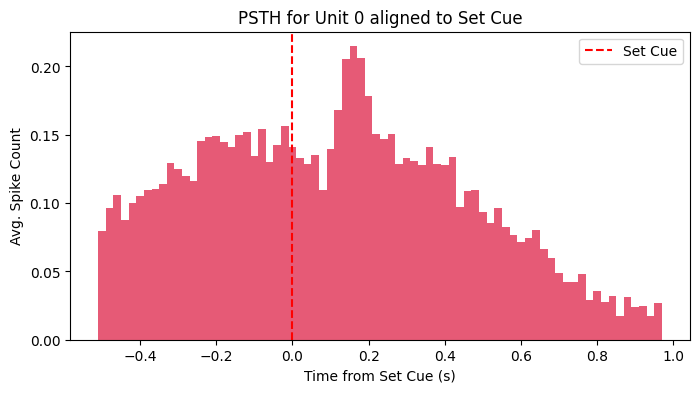

In [16]:
# Extract 'set_time' events
set_times = nwbfile.intervals['trials']['set_time'][:]

# Parameters for alignment
window_before = 0.5  # seconds
window_after = 1.0   # seconds
bin_size = 0.02
bins = np.arange(-window_before, window_after, bin_size)

# Calculate mean activity across all trials for the first unit
unit_id = 0
spike_times = nwbfile.units['spike_times'][unit_id]
psth = np.zeros(len(bins) - 1)

for t in set_times:
    # Get spikes in window around this specific trial's set_time
    trial_spikes = spike_times[(spike_times >= t - window_before) & (spike_times <= t + window_after)]
    # Shift spikes to be relative to the 'set_time'
    counts, _ = np.histogram(trial_spikes - t, bins=bins)
    psth += counts

# Normalize by number of trials to get average spike counts
psth = psth / len(set_times)

# Plotting
plt.figure(figsize=(8, 4))
plt.bar(bins[:-1], psth, width=bin_size, color='crimson', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Set Cue')
plt.title(f'PSTH for Unit {unit_id} aligned to Set Cue')
plt.xlabel('Time from Set Cue (s)')
plt.ylabel('Avg. Spike Count')
plt.legend()
plt.show()

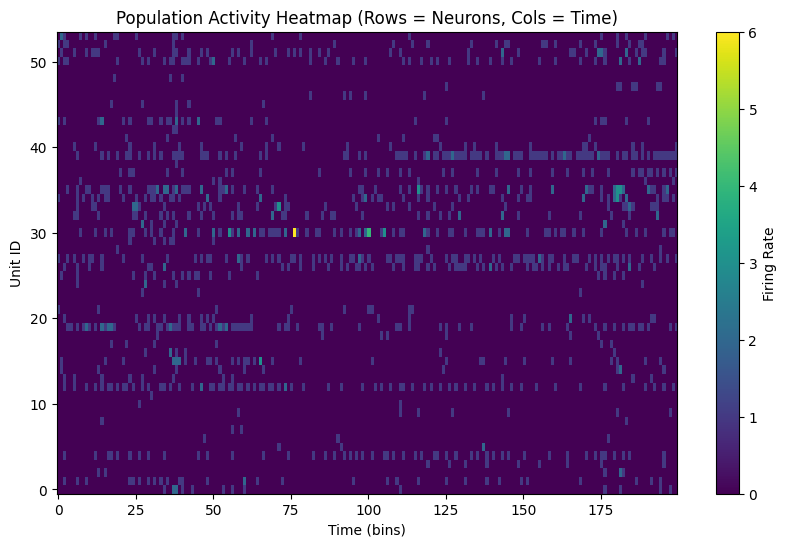

In [18]:
# 1. Define the interval for all trials (Set to Go)
# We look at the population activity (all 54 units)
# Create a matrix of (Time x Units) averaged across trials
num_bins = 50 # Adjust as needed
time_bins = np.linspace(0, 1.0, num_bins) # Assuming ~1s interval
population_activity = np.zeros((num_bins, train_matrix.shape[1]))

for i, start in enumerate(set_times):
    # Ensure we don't go out of bounds
    stop = go_times[i]
    if stop > start:
        # Get data in this interval
        indices = np.linspace(0, len(time_bins)-1, int((stop-start)/0.02)).astype(int)
        # Simplified: average activity per unit during this interval
        # In a real analysis, you would map this to the specific time bins
        
# 2. Plot the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(train_matrix[100:300, :].T, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Firing Rate')
plt.title('Population Activity Heatmap (Rows = Neurons, Cols = Time)')
plt.xlabel('Time (bins)')
plt.ylabel('Unit ID')
plt.show()

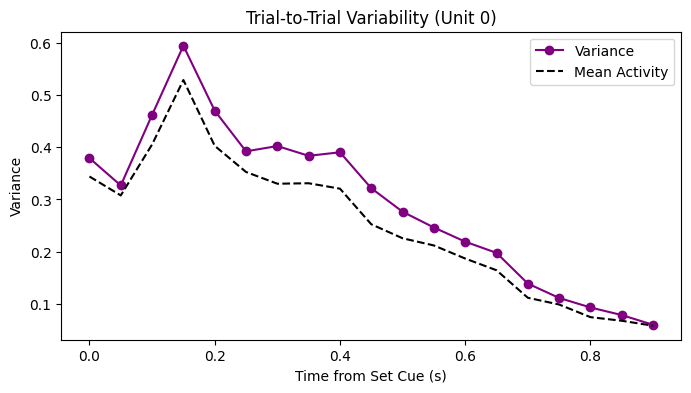

In [19]:
# 1. Align all trials for a specific unit (e.g., Unit 0)
unit_id = 0
spike_times = nwbfile.units['spike_times'][unit_id]
set_times = nwbfile.intervals['trials']['set_time'][:]

# Parameters
window_after = 1.0 
bin_size = 0.05
bins = np.arange(0, window_after, bin_size)
trial_activity = []

# 2. Extract firing rate per trial
for t in set_times:
    trial_spikes = spike_times[(spike_times >= t) & (spike_times <= t + window_after)]
    counts, _ = np.histogram(trial_spikes - t, bins=bins)
    trial_activity.append(counts)

trial_activity = np.array(trial_activity)

# 3. Calculate Variance across trials (columns = time bins)
variance_per_bin = np.var(trial_activity, axis=0)
mean_per_bin = np.mean(trial_activity, axis=0)

# 4. Plot
plt.figure(figsize=(8, 4))
plt.plot(bins[:-1], variance_per_bin, color='purple', marker='o', label='Variance')
plt.plot(bins[:-1], mean_per_bin, color='black', linestyle='--', label='Mean Activity')
plt.title(f'Trial-to-Trial Variability (Unit {unit_id})')
plt.xlabel('Time from Set Cue (s)')
plt.ylabel('Variance')
plt.legend()
plt.show()

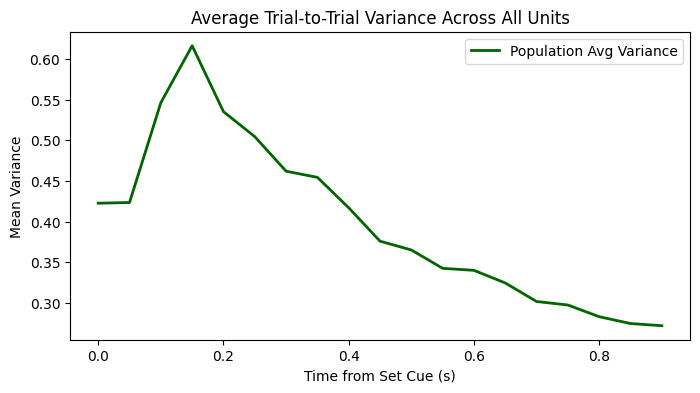

In [20]:
# Calculate mean variance across all 54 units
all_variances = []
num_units = train_matrix.shape[1]

for u in range(num_units):
    unit_spikes = nwbfile.units['spike_times'][u]
    trial_vars = []
    
    for t in set_times:
        # Extract activity per trial for this unit
        trial_spikes = unit_spikes[(unit_spikes >= t) & (unit_spikes <= t + window_after)]
        counts, _ = np.histogram(trial_spikes - t, bins=bins)
        trial_vars.append(counts)
    
    # Calculate variance for this unit and store it
    all_variances.append(np.var(trial_vars, axis=0))

# Average the variance across all units
mean_pop_variance = np.mean(all_variances, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(bins[:-1], mean_pop_variance, color='darkgreen', linewidth=2, label='Population Avg Variance')
plt.title('Average Trial-to-Trial Variance Across All Units')
plt.xlabel('Time from Set Cue (s)')
plt.ylabel('Mean Variance')
plt.legend()
plt.show()

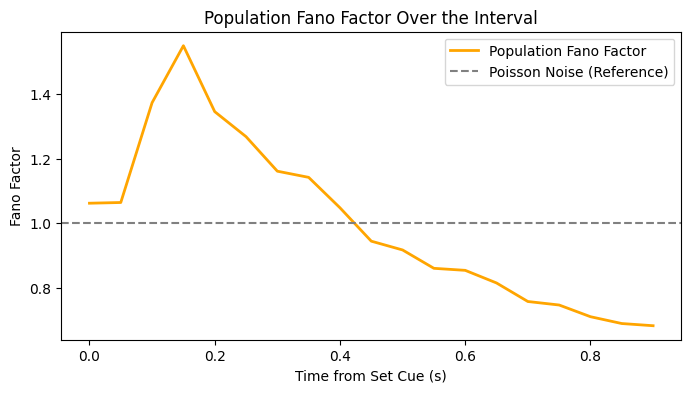

In [21]:
# Calculate Fano Factor: Var(count) / Mean(count) for each time bin
# We use a small epsilon to avoid division by zero
fano_factor = mean_pop_variance / (np.mean(np.array([np.mean(trial_vars, axis=0) for trial_vars in all_variances]), axis=0) + 1e-6)

plt.figure(figsize=(8, 4))
plt.plot(bins[:-1], fano_factor, color='orange', linewidth=2, label='Population Fano Factor')
plt.axhline(1, color='gray', linestyle='--', label='Poisson Noise (Reference)')
plt.title('Population Fano Factor Over the Interval')
plt.xlabel('Time from Set Cue (s)')
plt.ylabel('Fano Factor')
plt.legend()
plt.show()

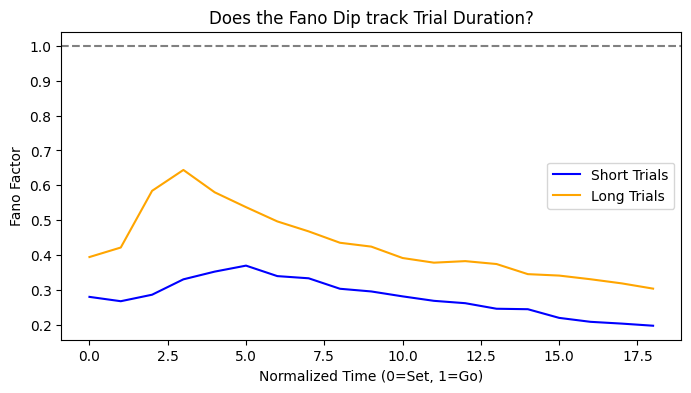

In [22]:
# 1. Identify short and long trials
is_short = nwbfile.intervals['trials']['is_short'][:]
set_times = nwbfile.intervals['trials']['set_time'][:]
go_times = nwbfile.intervals['trials']['go_time'][:]

# 2. Function to calculate Fano Factor for a subset of trials
def get_fano_for_trials(trial_indices):
    all_vars = []
    # Using the same bins as before
    for u in range(num_units):
        unit_spikes = nwbfile.units['spike_times'][u]
        trial_vars = []
        for idx in trial_indices:
            t = set_times[idx]
            duration = go_times[idx] - t
            # Only look at the interval up to the Go cue
            # (adjusting bins for the specific trial duration)
            local_bins = np.linspace(0, duration, 20)
            trial_spikes = unit_spikes[(unit_spikes >= t) & (unit_spikes <= t + duration)]
            counts, _ = np.histogram(trial_spikes - t, bins=local_bins)
            trial_vars.append(counts)
        all_vars.append(np.var(trial_vars, axis=0))
    return np.mean(all_vars, axis=0)

# 3. Compute and Plot
short_fano = get_fano_for_trials(np.where(is_short)[0])
long_fano = get_fano_for_trials(np.where(~is_short)[0])

plt.figure(figsize=(8, 4))
plt.plot(short_fano, label='Short Trials', color='blue')
plt.plot(long_fano, label='Long Trials', color='orange')
plt.axhline(1, color='gray', linestyle='--')
plt.title('Does the Fano Dip track Trial Duration?')
plt.xlabel('Normalized Time (0=Set, 1=Go)')
plt.ylabel('Fano Factor')
plt.legend()
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

# 1. Standardize the data
# We scale each unit (column) to have mean=0 and variance=1
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(train_matrix)

# 2. Vstack (if you wanted to combine multiple datasets, e.g., Train + Test)
# Assuming you want to look at the combined activity:
combined_data = np.vstack([scaled_matrix]) 

print(f"Scaled matrix shape: {combined_data.shape}")

Scaled matrix shape: (240467, 54)


Explained variance ratio: [0.05295046 0.02847891 0.02590123]


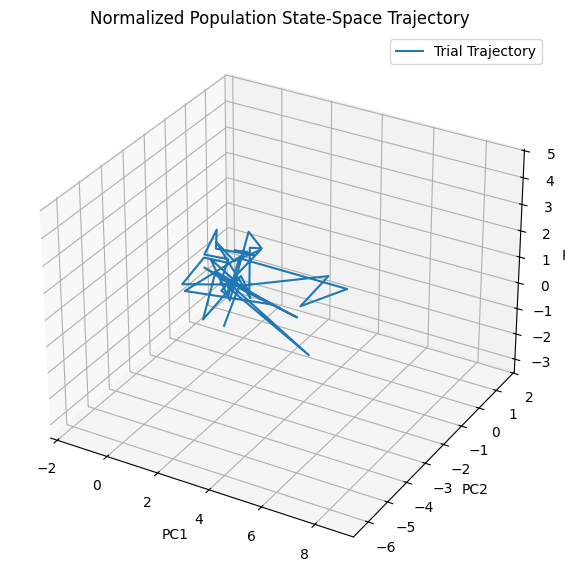

In [24]:
from sklearn.decomposition import PCA

# 1. Initialize and fit PCA
pca = PCA(n_components=3) 
pca_result = pca.fit_transform(combined_data)

# 2. Check Explained Variance
# This tells you how much of the population dynamic is captured in these 3 components
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# 3. Plot the 3D Trajectory for a trial
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Example: Plot one Long trial (using set_times/go_times from before)
t_start = int(set_times[0] / 0.02)
t_end = int(go_times[0] / 0.02)
ax.plot(pca_result[t_start:t_end, 0], 
        pca_result[t_start:t_end, 1], 
        pca_result[t_start:t_end, 2], label='Trial Trajectory')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Normalized Population State-Space Trajectory')
plt.legend()
plt.show()

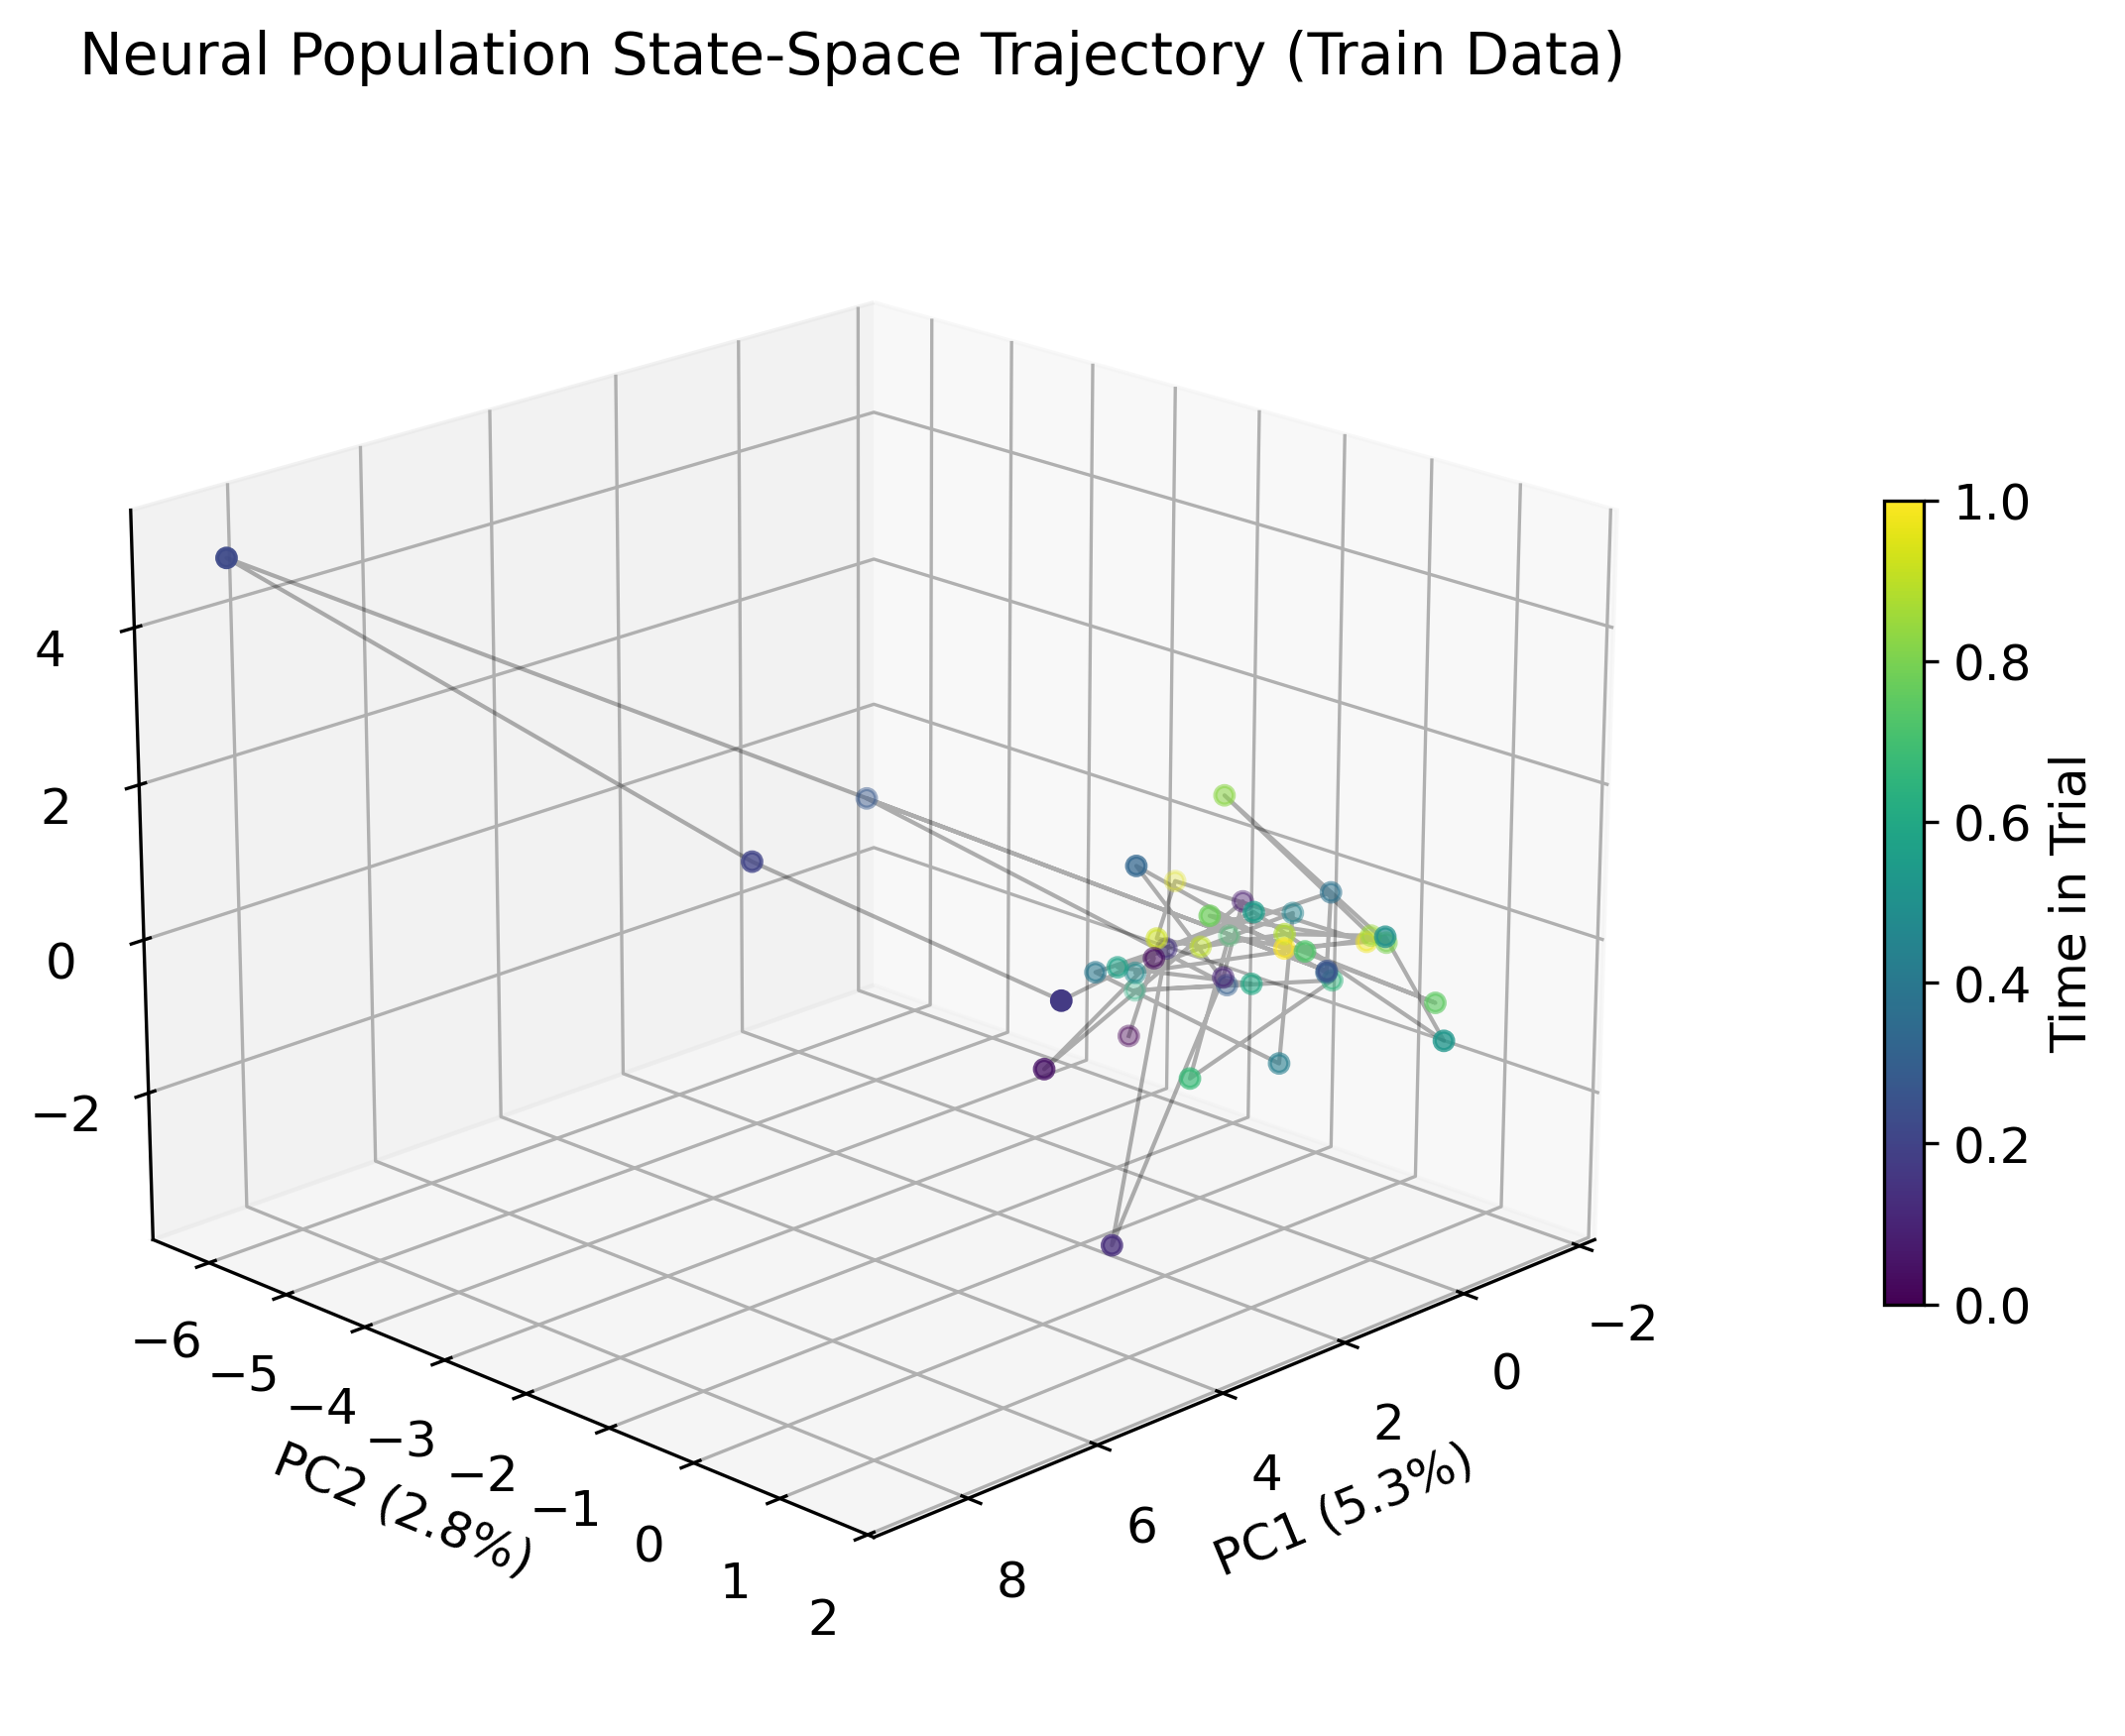

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Journal Aesthetic Configuration
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 300,  # High resolution for publication
    'axes.grid': True,
    'grid.alpha': 0.3
})

# 2. Setup the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. Extract Trajectory Data
trial_idx = 0 
t_start = int(set_times[trial_idx] / 0.02)
t_end = int(go_times[trial_idx] / 0.02)
path = pca_result[t_start:t_end, :3]

# 4. Create Color Gradient (Time-based)
# This helps the viewer follow the progression of time along the trajectory
colors = np.linspace(0, 1, len(path))
sc = ax.scatter(path[:, 0], path[:, 1], path[:, 2], c=colors, cmap='viridis', s=20)

# 5. Plot the connecting line
ax.plot(path[:, 0], path[:, 1], path[:, 2], color='black', alpha=0.3, linewidth=1)

# 6. Formatting Labels with Explained Variance
ev = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
ax.set_zlabel(f'PC3 ({ev[2]:.1%})')
ax.set_title('Neural Population State-Space Trajectory (Train Data)')

# 7. Final Polish
ax.view_init(elev=20, azim=45) # Set a nice viewing angle
cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Time in Trial')

plt.tight_layout()
plt.show()

In [29]:
# 1. Check if we can align by index (assuming they are the same first 40 units)
# If the test set only has 40 units, we must use only the first 40 units of the training set
# to make the StandardScaler compatible.

# Re-fit/Transform only using the first 40 units
scaled_train_reduced = train_matrix[:, :40] 

# Now fit the scaler on the reduced training data
scaler = StandardScaler()
scaler.fit(scaled_train_reduced)

# Now you can transform both sets using the new, compatible scaler
scaled_train = scaler.transform(scaled_train_reduced)
scaled_test = scaler.transform(test_matrix)

# 2. Now fit PCA on the reduced, standardized training data
pca = PCA(n_components=3)
pca.fit(scaled_train)

# 3. Now the test transformation will work
pca_test_result = pca.transform(scaled_test)

In [31]:
print(test_nwbfile.intervals['trials'].colnames)

('start_time', 'stop_time', 'go_time', 'split')


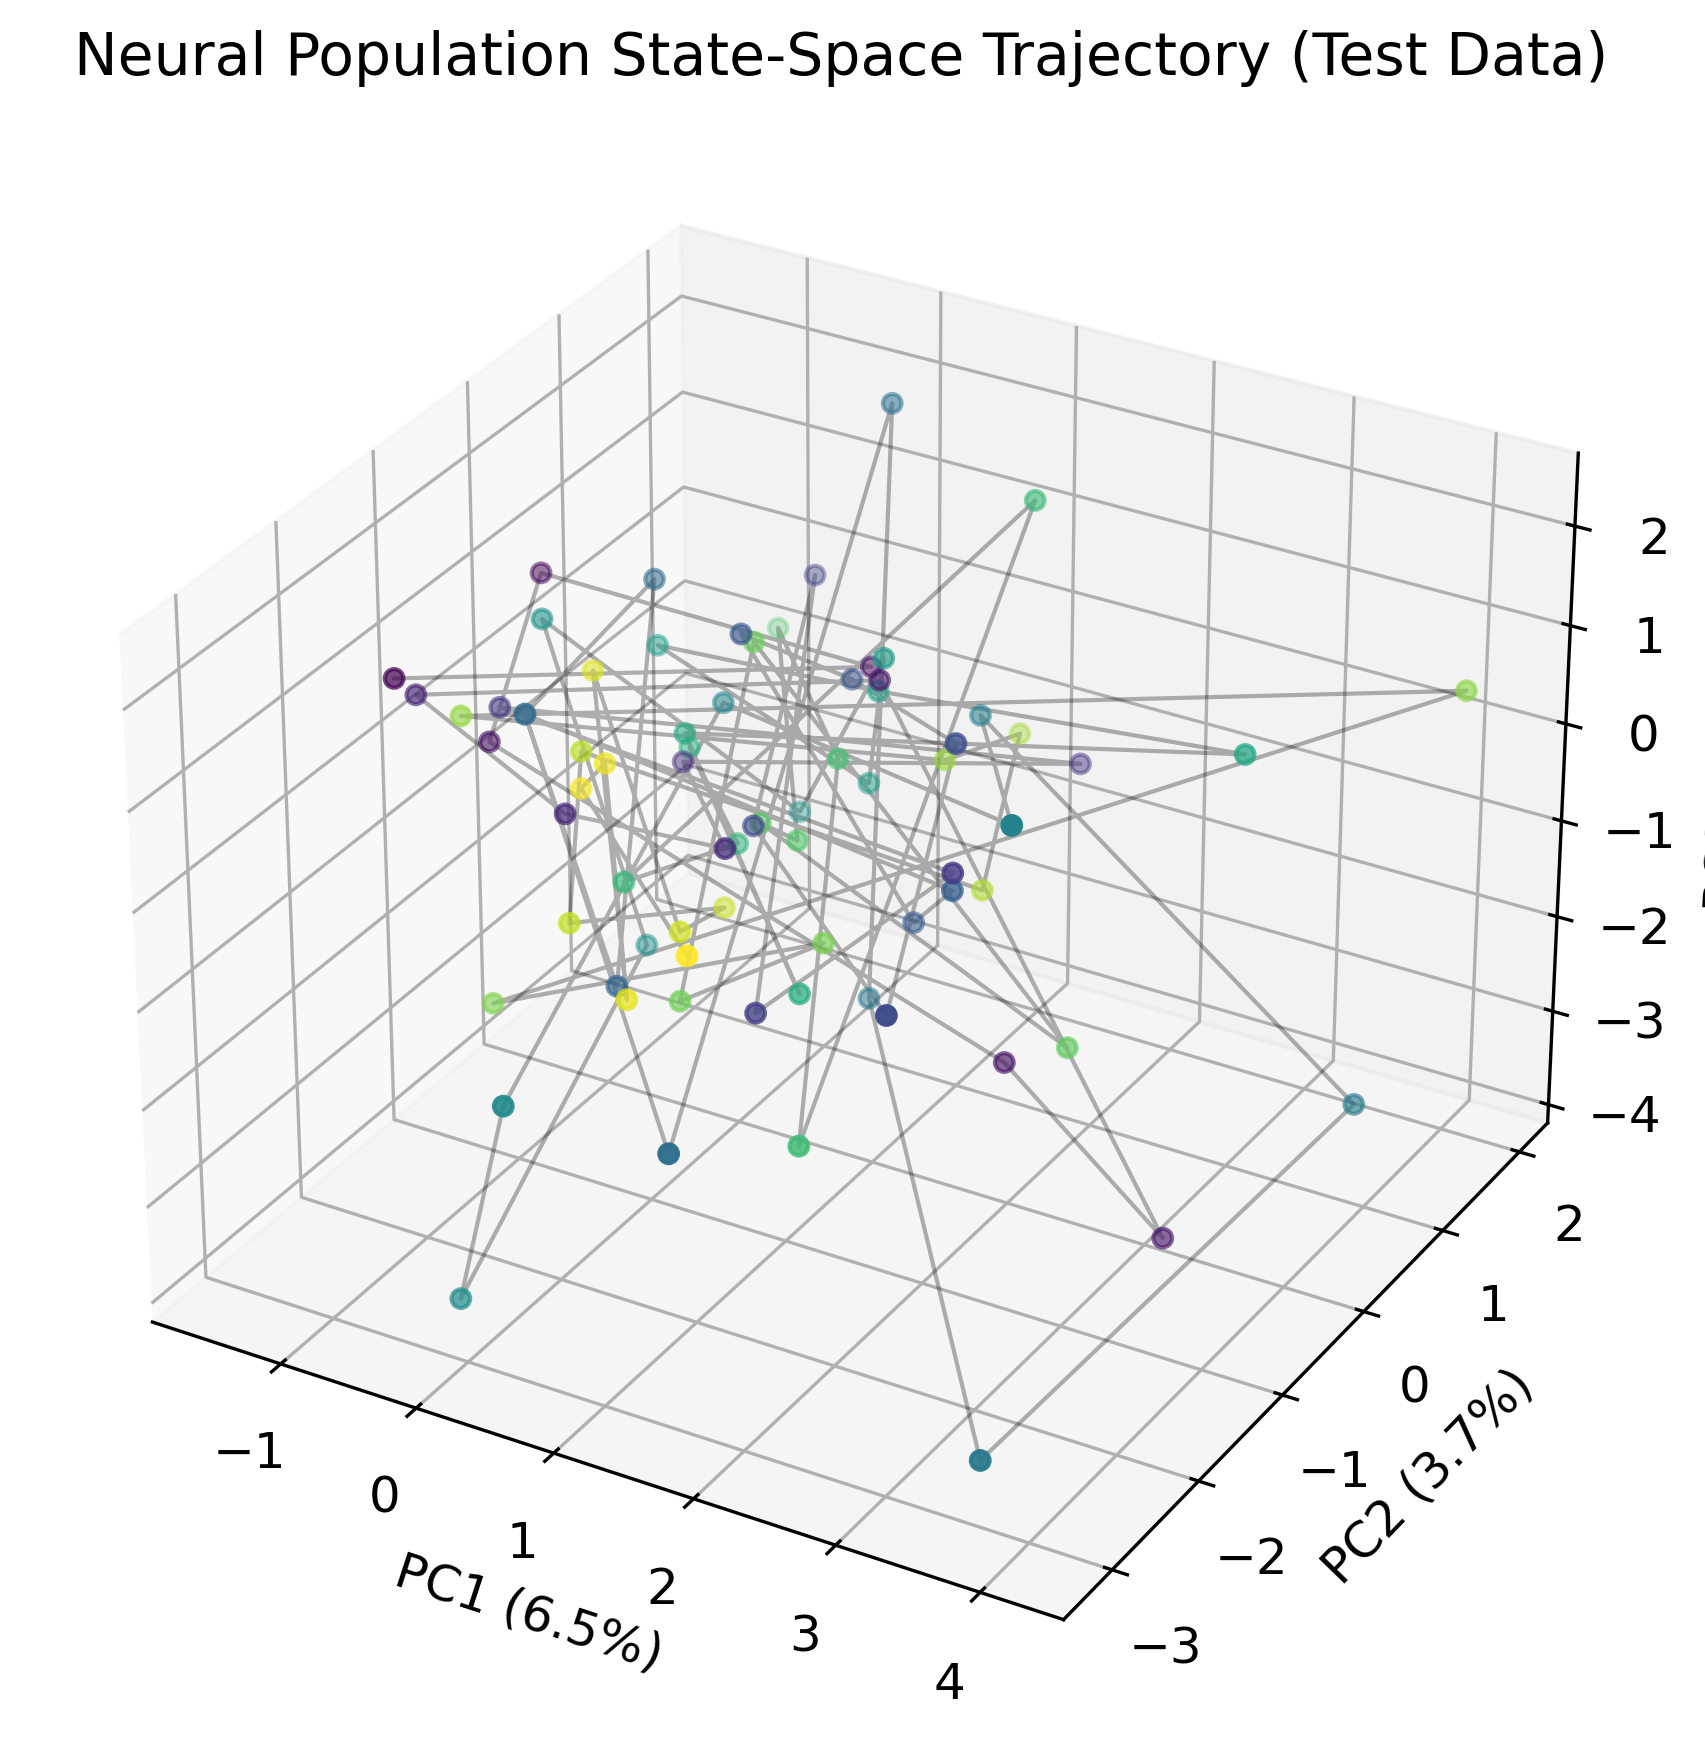

In [32]:
# 1. Transform the test data using the training-fitted scaler and pca
# Important: Do not 'fit' again, just 'transform'
scaled_test = scaler.transform(test_matrix)
pca_test_result = pca.transform(scaled_test)

# 2. Setup the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. Extract Trajectory for a sample test trial
# We use the test_nwbfile intervals to get valid indices
test_set_times = test_nwbfile.intervals['trials']['start_time'][:]
test_go_times = test_nwbfile.intervals['trials']['go_time'][:]

trial_idx = 0 
t_start = int(test_set_times[trial_idx] / 0.02)
t_end = int(test_go_times[trial_idx] / 0.02)
path = pca_test_result[t_start:t_end, :3]

# 4. Create Color Gradient
colors = np.linspace(0, 1, len(path))
sc = ax.scatter(path[:, 0], path[:, 1], path[:, 2], c=colors, cmap='viridis', s=20)
ax.plot(path[:, 0], path[:, 1], path[:, 2], color='black', alpha=0.3, linewidth=1)

# 5. Labels
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax.set_title('Neural Population State-Space Trajectory (Test Data)')

plt.tight_layout()
plt.show()

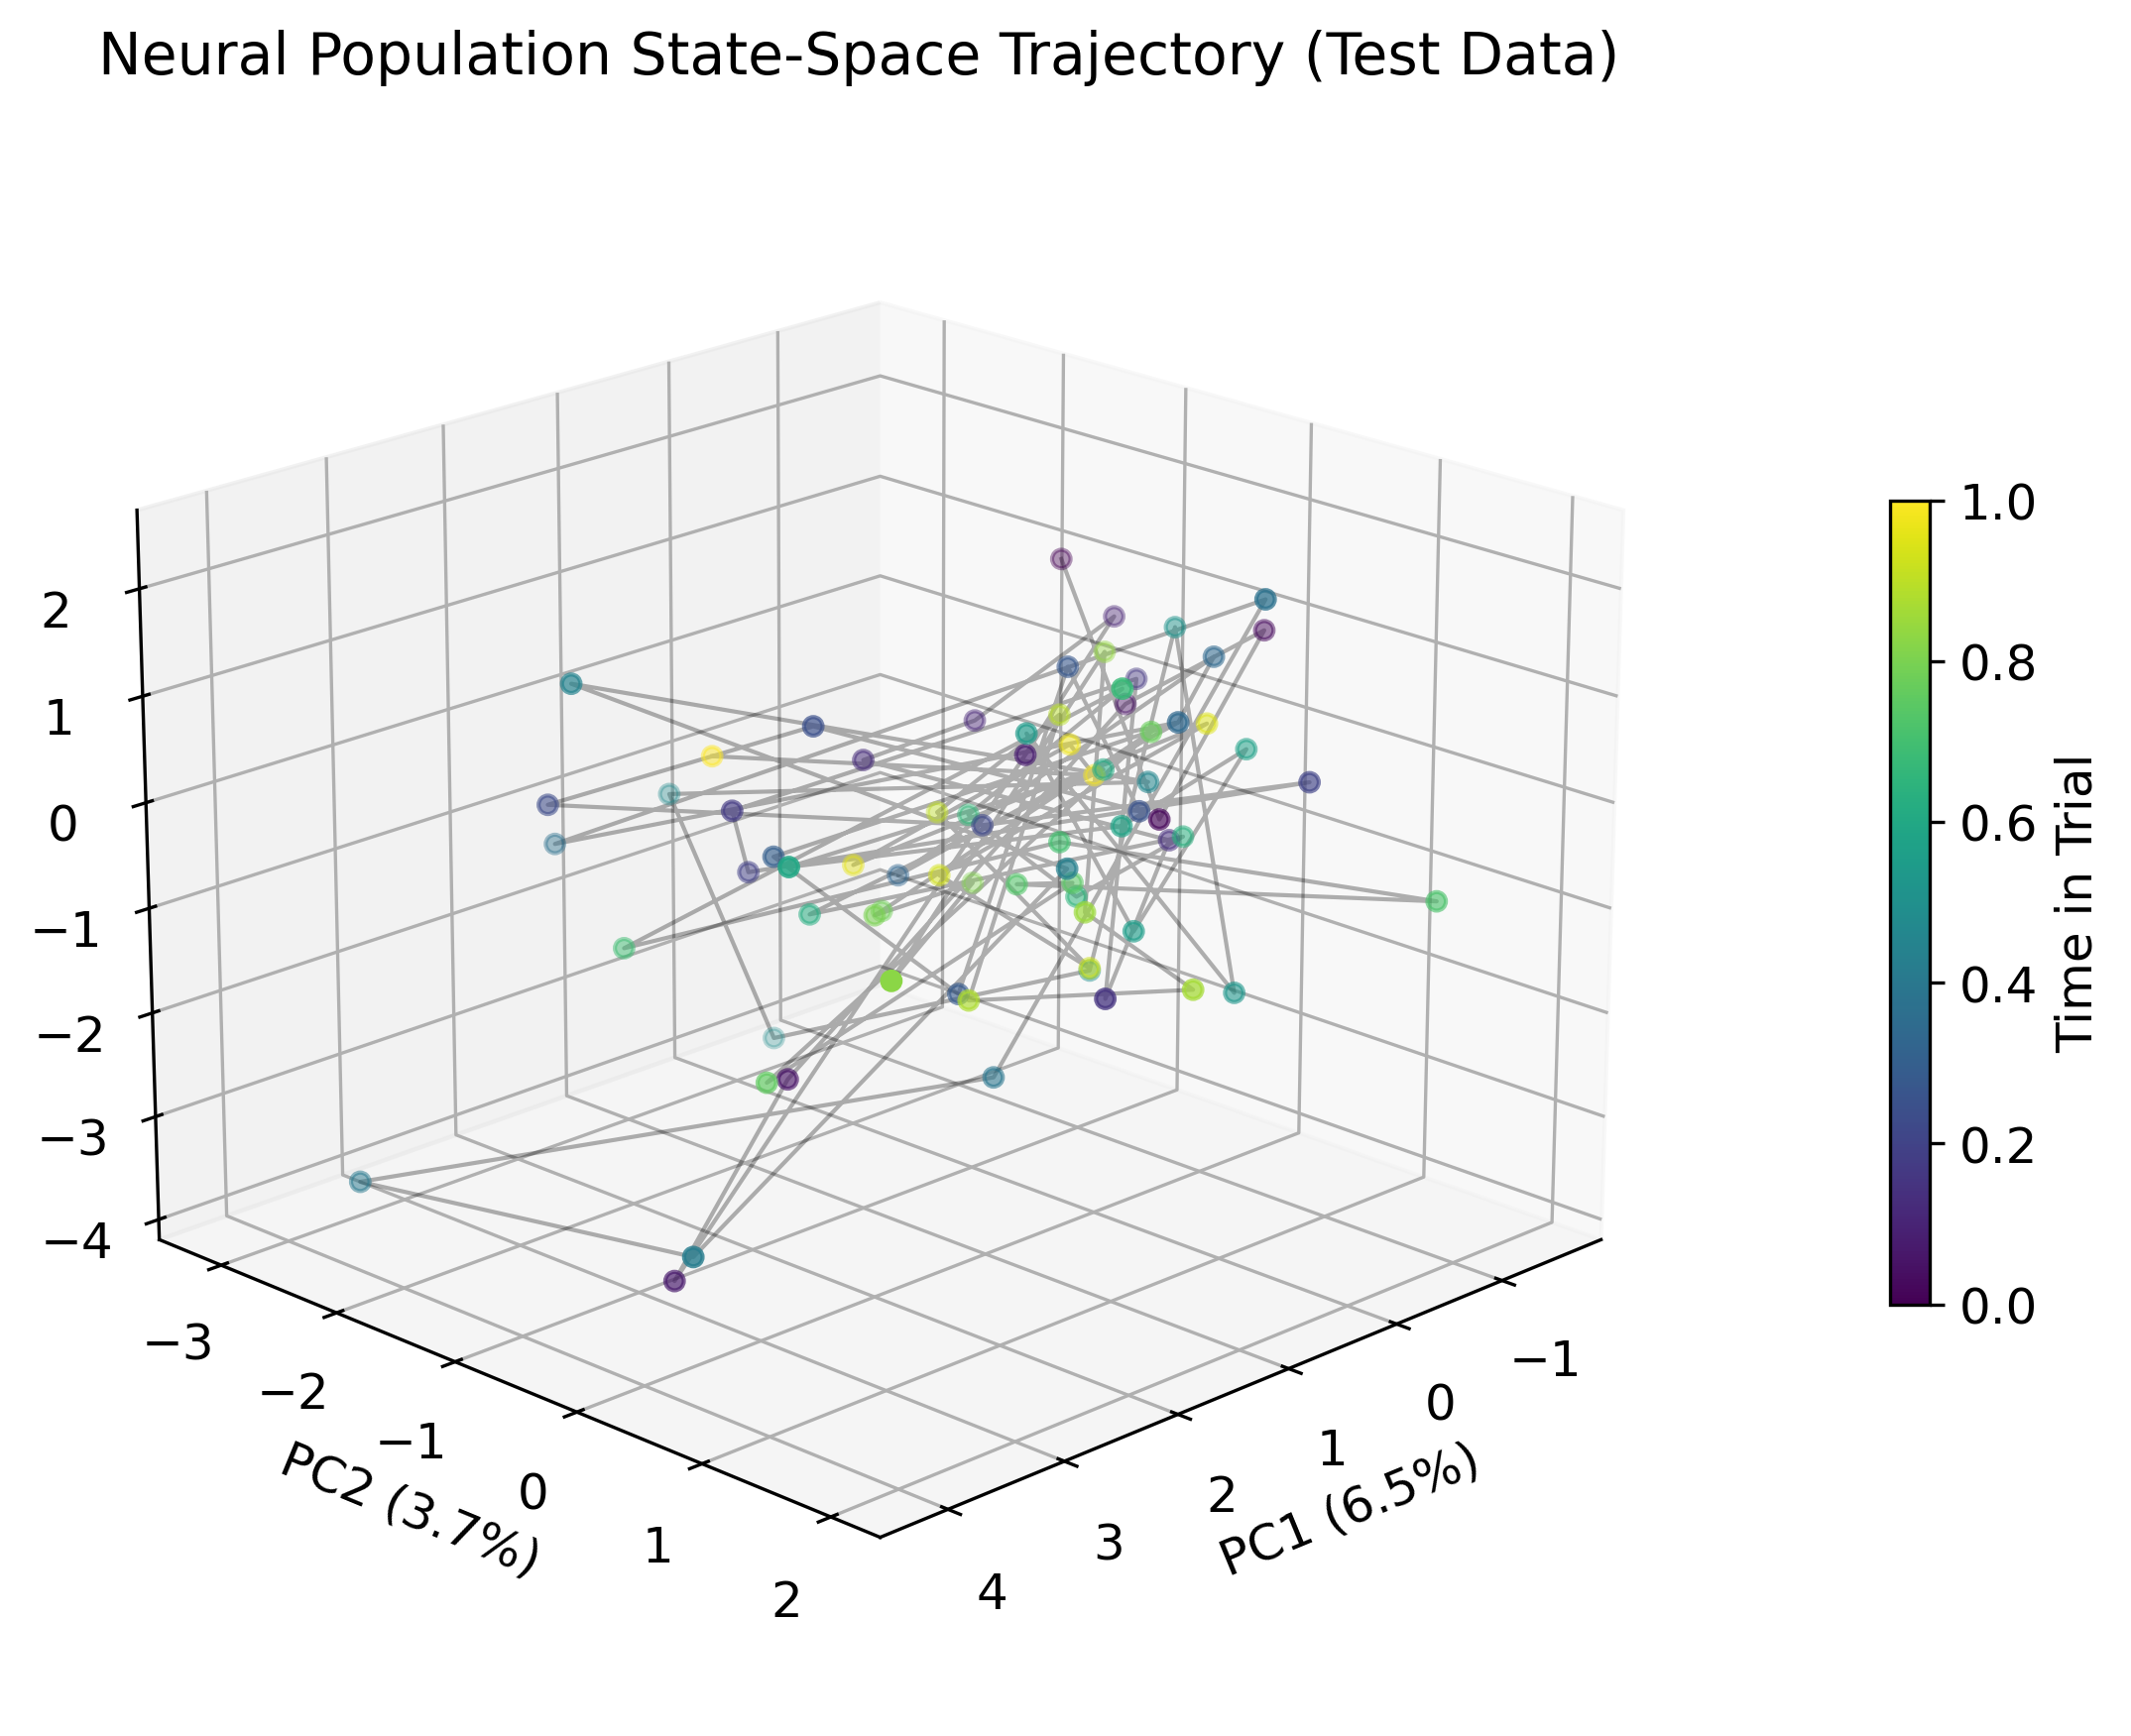

In [33]:

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# 2. Setup the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. Extract Trajectory Data (Using test-specific variables)
trial_idx = 0 
t_start = int(test_set_times[trial_idx] / 0.02)
t_end = int(test_go_times[trial_idx] / 0.02)
# Ensure we use pca_test_result here
path = pca_test_result[t_start:t_end, :3]

# 4. Create Color Gradient (Time-based)
colors = np.linspace(0, 1, len(path))
sc = ax.scatter(path[:, 0], path[:, 1], path[:, 2], c=colors, cmap='viridis', s=20)

# 5. Plot the connecting line
ax.plot(path[:, 0], path[:, 1], path[:, 2], color='black', alpha=0.3, linewidth=1)

# 6. Formatting Labels (Using the pca model fitted on training data)
ev = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
ax.set_zlabel(f'PC3 ({ev[2]:.1%})')
ax.set_title('Neural Population State-Space Trajectory (Test Data)')

# 7. Final Polish
ax.view_init(elev=20, azim=45)
cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Time in Trial')

plt.tight_layout()
plt.show()